In [1632]:
import numpy as np
import matplotlib.pyplot as plt     

In [1633]:
%%bash

g++ -std=c++17 -Wall RampCoarse.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:393:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  393 |         bool ghost_flag = false;
      |              ^~~~~~~~~~


In [1634]:
%%bash
./myprogram

Shape = (832, 4)
setting pointersSetting ambient Conditions...Setting inflow Conditions...Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17


Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
Iteration: 72
Iteration: 73
Iteration: 74
Iteration: 75
Iteration: 76
Iteration: 77
Iteration: 78
Iteration: 79
Iteration: 80
Iteration: 81
Iteration: 82
Iteration: 83
Iteration: 84
Iteration: 85
Iteration: 86
Iteration: 87
Iteration: 88
Iterat

array([17.1577688 , 30.13823767])

In [1636]:


data = np.loadtxt("primitives.csv", delimiter=",")
NI = 16
NJ = 52
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 832)


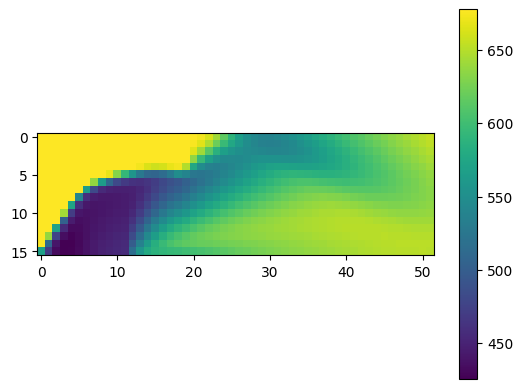

In [1637]:
plt.imshow(u[::-1])
plt.colorbar()

In [1638]:
from PostprocessingFunctions import load_grid
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Inlet.53x17.grd")



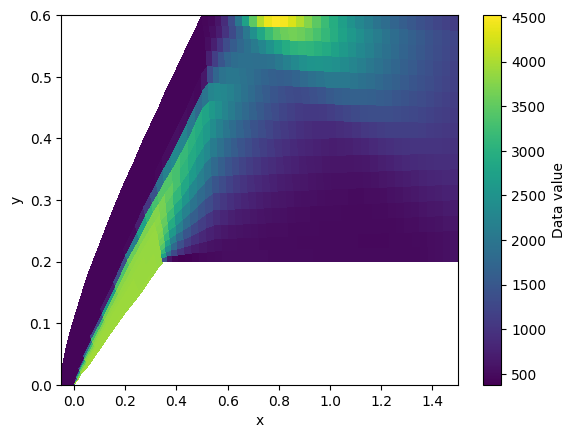

In [1645]:
 

plt.pcolormesh(x, y, p, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



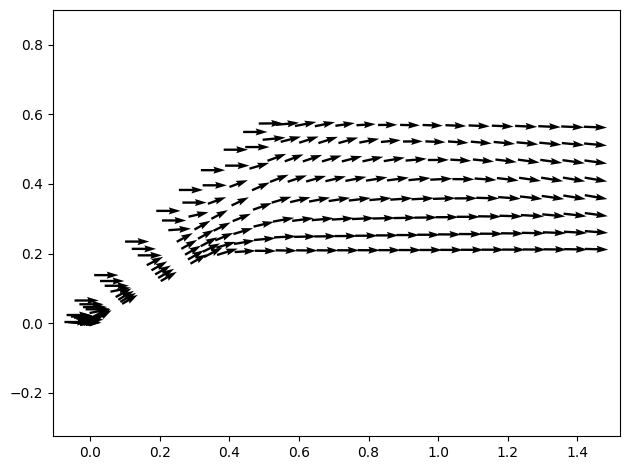

In [1640]:
# import numpy as np
# import matplotlib.pyplot as plt

# def quiver_at_cell_centers(x, y, u, v, step=1, scale=None):
#     Ny, Nx = u.shape

#     # Case 1: x,y are 2D edge grids (Ny+1, Nx+1) -> average corners to centers
#     if x.shape == (Ny+1, Nx+1) and y.shape == (Ny+1, Nx+1):
#         Xc = 0.25*(x[:-1,:-1] + x[1:,:-1] + x[:-1,1:] + x[1:,1:])
#         Yc = 0.25*(y[:-1,:-1] + y[1:,:-1] + y[:-1,1:] + y[1:,1:])
#     # Case 2: x,y are 1D edge arrays (Nx+1) & (Ny+1)
#     elif x.ndim == 1 and y.ndim == 1 and x.size == Nx+1 and y.size == Ny+1:
#         xc = 0.5*(x[:-1] + x[1:])
#         yc = 0.5*(y[:-1] + y[1:])
#         Xc, Yc = np.meshgrid(xc, yc)
#     # Case 3: assume x,y already at centers (Ny, Nx)
#     else:
#         Xc, Yc = x, y

#     plt.quiver(Xc[::step, ::step],
#                Yc[::step, ::step],
#                u[::step, ::step],
#                v[::step, ::step],
#                pivot='mid', angles='xy', scale_units='xy', scale=scale)
#     plt.axis('equal'); plt.tight_layout(); plt.show()
# quiver_at_cell_centers(x, y, u, v, step=2)

In [1641]:
epsilon = 1e-10
gamma = 1.4
def vanleer_flux_cell(CELL_L,CELL_R,nx,ny):
    return f_convective_cell(CELL_L,CELL_R, nx,ny)+f_pressure_flux_cell(CELL_L,CELL_R, nx,ny)

def f_pressure_flux_cell(CELL_L,CELL_R,nx,ny):

    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)



    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx+ny*v_R
    
    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    p_doubleBar_plus = M_plus*(-M_L+2)
    p_doubleBar_minus = M_minus*(-M_R-2)

    D_plus = alpha_plus*(1+beta_L)-beta_L*p_doubleBar_plus
    D_minus = alpha_minus*(1+beta_R)-beta_R*p_doubleBar_minus

    temp_zero = np.zeros_like(p_L)
    

    return np.array([temp_zero,nx*D_plus*p_L,ny*D_plus*p_L,temp_zero])+\
        np.array([temp_zero,nx*D_minus*p_R,ny*D_minus*p_R,temp_zero])

def c_plus_minus(alpha_plus_minus,beta_LR,mach_LR,M_plus_minus):
    return alpha_plus_minus*(1+beta_LR)*mach_LR-beta_LR*M_plus_minus


def f_convective_cell(CELL_L,CELL_R,nx,ny):
    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)
    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx +ny*v_R



    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    
    ht_L = (gamma / (gamma - 1)) * (p_L / rho_L) + 0.5 * (u_L**2+v_R**2)
    ht_R = (gamma / (gamma - 1)) * (p_R / rho_R) + 0.5 * (u_R**2+v_R**2)

    temp_L = rho_L*a_L*c_plus_minus(alpha_plus,beta_L,M_L,M_plus)
    temp_R = rho_R*a_R*c_plus_minus(alpha_minus,beta_R,M_R,M_minus)
    FC_i_half = np.array([temp_L,u_L*temp_L,v_L*temp_L,ht_L*temp_L])+np.array([temp_R,u_R*temp_R,v_R*temp_R,ht_R*temp_R])

    return FC_i_half 

def prim_to_cons(W, gamma=1.4):
    """
    W: iterable of length 4 -> [rho, u, v, p]
    returns [rho, rho*u, rho*v, rho*E]
    """
    rho, u, v, p = W
    rho_u = rho * u
    rho_v = rho * v
    rho_E = p / (gamma - 1.0) + 0.5 * rho * (u*u + v*v)  # rho*e + kinetic
    return [rho, rho_u, rho_v, rho_E]


In [1642]:
Cell_L =  [0.761065,34,0,65396.9]
Cell_R = [.761065,17.34,30.073,65396.9]
vanleer_flux_cell(Cell_L,Cell_R,.5,-.86)

array([-7.69750387e-02,  3.63226421e+04, -6.25825155e+04,  7.86028891e+03])

In [1643]:
CELL_L = []
VL = [.157,531,0,7201]
VM = [0.764876, 0,0,65855.8  ]
VR = VM
FL =  vanleer_flux_cell(VL,VM,-1,0)
FR  = vanleer_flux_cell(VM,VR,1,0)
FR +FL

array([-6.63890659e+01,  3.29279000e+04,  0.00000000e+00, -2.00063379e+07])

In [1644]:
import Nozzle_2D_checkpoint4_2 as Nozzle

Nozzle("RAMP_inputs.nml")

ModuleNotFoundError: No module named 'Nozzle_2D_checkpoint4_2'

In [ ]:
NI = 17  # same as in C++
NJ = 53
#x = np.fromfile("Ramp_Coarse_xx.bin", dtype=np.float64).reshape((NI,NJ))
#y = np.fromfile("Ramp_Coarse_yy.bin",dtype=np.float64).reshape((NI,NJ))

#x = np.loadtxt("Ramp_Coarse_xx.csv", delimiter=",",dtype=np.float64).reshape((NI,NJ))
#y = np.loadtxt("Ramp_Coarse_yy.csv",delimiter=",",dtype=np.float64).reshape((NI,NJ))
#np.savetxt("Ramp_Coarse_xx.csv",x,delimiter=",")
#np.savetxt("Ramp_Coarse_yy.csv",y,delimiter=",")


In [ ]:
import matplotlib.pyplot as plt

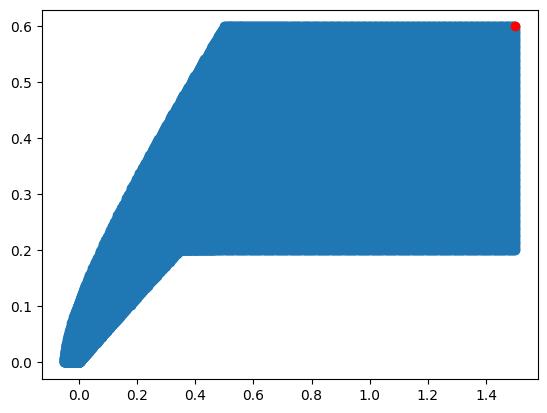

In [ ]:
from PostprocessingFunctions import load_grid

x,y = load_grid("Meshes/Ramp/Inlet.417x129.grd")

plt.scatter(x[::-1],y[::-1])
plt.plot((x[::-1])[0,-1],(y[::-1])[0,-1],"o",color = "red")


x_temp = x[::-1]
y_temp = y[::-1]

x11 = x[0:-1,0:-1]
x12 = x[0:-1,1:]
x21 = x[1:,0:-1]
x22 = x[1:,1:]

y11 = y[0:-1,0:-1]
y12 = y[0:-1,1:]
y21 = y[1:,0:-1]
y22 = y[1:,1:]

In [ ]:
x_cells= np.array([x21,x22,x11,x12])
y_cells = np.array([y21,y22,y11,y12])


In [ ]:
x_cells = x_cells.reshape((4,x11.shape[0]*x11.shape[1]))
y_cells = y_cells.reshape((4,x11.shape[0]*x11.shape[1]))

#np.savetxt("Meshes/Ramp/Ramp_Fine_cells_xx.csv",(x_cells.T).copy(),delimiter=",")
#np.savetxt("Meshes/Ramp/Ramp_Fine_cells_yy.csv",(y_cells.T).copy(),delimiter=",")

In [ ]:
x_cells.shape

(4, 832)

In [ ]:
fig, ax = plt.subplots(figsize=(12,12))
for j in range(xx.shape[1]):
    ax.plot(xx[:, j], yy[:, j], 'k-', linewidth=0.5)

# Plot horizontal lines (loop over rows)
for i in range(xx.shape[0]):
    ax.plot(xx[i, :], yy[i, :], 'k-', linewidth=0.5)
index = 51
plt.scatter(x_cells[:,index],y_cells[:,index],c=x_cells[:,index])
plt.colorbar()

NameError: name 'plt' is not defined

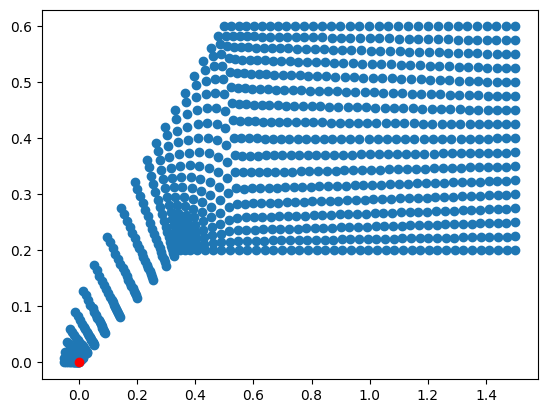

In [ ]:
plt.scatter(x,y)
plt.plot(x[0,0],y[0,0],"o",color="red")

In [ ]:
NI = 16  # same as in C++
NJ = 52
NI = 128  # same as in C++
NJ = 416
#midpointxx = np.fromfile("midpoint_xx.bin", dtype=np.float64).reshape((NI-1, NJ-1))
#midpointyy = np.fromfile("midpoint_yy.bin", dtype=np.float64).reshape((NI-1, NJ-1))
volume = np.fromfile("volume2.bin", dtype=np.float64).reshape((NI, NJ))
#plt.scatter(midpointxx,midpointyy,c=volume)

ValueError: cannot reshape array of size 3328 into shape (128,416)

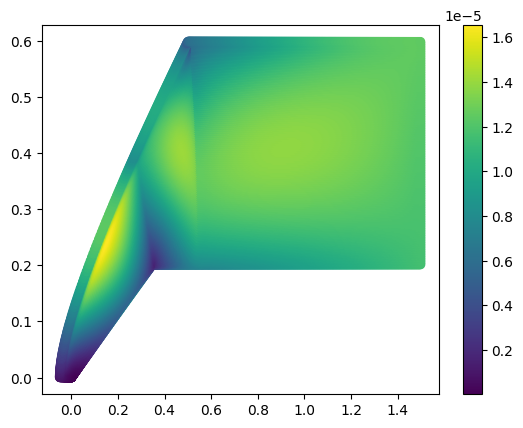

(array([[ 3.09538852e-05,  2.57089569e-04,  5.07104051e-04, ...,
          1.49072233e+00,  1.49443307e+00,  1.49814421e+00],
        [-1.34020211e-04,  7.94836694e-05,  3.38726487e-04, ...,
          1.49072001e+00,  1.49443096e+00,  1.49814323e+00],
        [-3.07137100e-04, -1.22740248e-04,  1.34852176e-04, ...,
          1.49071545e+00,  1.49442764e+00,  1.49814195e+00],
        ...,
        [-4.74712089e-02, -4.74373894e-02, -4.73874514e-02, ...,
          1.48999416e+00,  1.49400267e+00,  1.49800257e+00],
        [-4.84590757e-02, -4.84190636e-02, -4.83693374e-02, ...,
          1.48998948e+00,  1.49399931e+00,  1.49800128e+00],
        [-4.94679912e-02, -4.94240628e-02, -4.93759254e-02, ...,
          1.48998713e+00,  1.49399720e+00,  1.49800031e+00]]),
 array([[6.95126410e-05, 2.14313835e-04, 3.68069006e-04, ...,
         2.01557390e-01, 2.01559824e-01, 2.01561784e-01],
        [8.92007223e-05, 2.68359475e-04, 4.45821691e-04, ...,
         2.04675250e-01, 2.04681961e-01, 2.0468

In [ ]:
from Nozzle_2D_checkpoint4_2 import Nozzle
nozzle = Nozzle("RAMP_inputs.nml")
nozzle.load_grid("Inlet.417x129.grd")
nozzle.compute_all_areas(visualize=True)

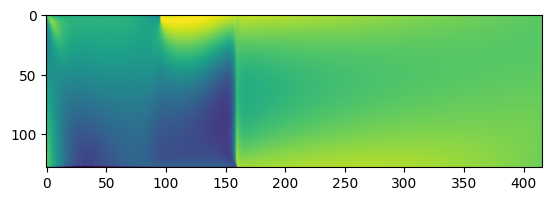

In [ ]:
plt.imshow(volume)

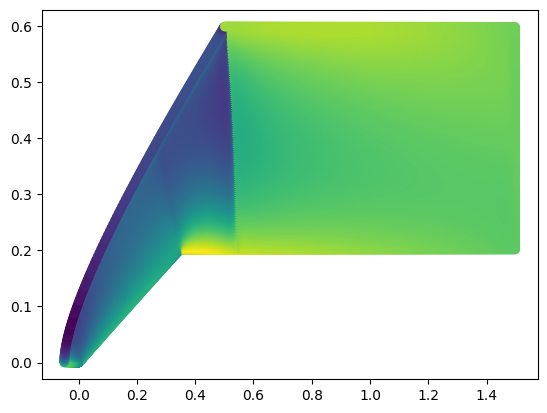

In [ ]:
plt.scatter(nozzle.midpointxx,nozzle.midpointyy,c=volume)

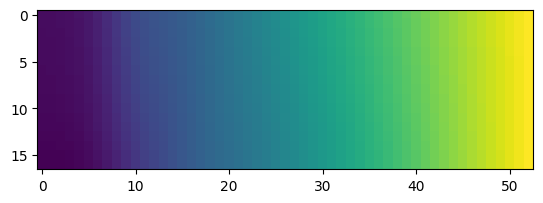

In [ ]:
plt.imshow(x)

-21.398941168849014


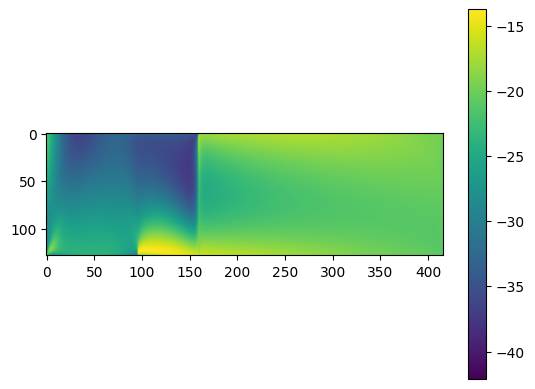

In [ ]:
print(np.median(volume))
plt.imshow(volume[::-1])
plt.colorbar()